# RELIANCE STOCK PRICE PREDICTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Reliance_stock_2024.csv")
df

,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,31-Dec-24,EQ,"1,208.00","1,219.10","1,206.15","1,210.70","1,216.40","1,215.45","1,213.08","3,217.60","1,201.50","64,05,475","7,77,03,38,353.90","1,80,916"
1,30-Dec-24,EQ,"1,216.40","1,223.20","1,208.10","1,221.05","1,211.50","1,210.70","1,214.71","3,217.60","1,201.50","88,18,766","10,71,22,29,377.50","3,08,317"
2,27-Dec-24,EQ,"1,218.30","1,227.90","1,217.00","1,216.55","1,221.50","1,221.05","1,223.20","3,217.60","1,201.50","70,00,397","8,56,28,95,530.20","1,74,882"
3,26-Dec-24,EQ,"1,224.25","1,227.70","1,214.25","1,222.75","1,217.00","1,216.55","1,219.74","3,217.60","1,201.50","1,00,16,178","12,21,71,76,986.80","2,56,436"
4,24-Dec-24,EQ,"1,222.30","1,233.55","1,221.00","1,222.30","1,224.20","1,222.75","1,227.14","3,217.60","1,201.50","67,34,917","8,26,46,75,853.25","2,07,746"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,5-Jan-24,EQ,"2,602.90","2,619.85","2,598.00","2,596.65","2,609.00","2,607.70","2,606.82","2,634.00","2,220.30","40,43,203","10,53,98,86,698.05","2,11,413"
245,4-Jan-24,EQ,"2,588.00","2,609.85","2,579.10","2,583.30","2,600.00","2,596.65","2,597.37","2,634.00","2,220.30","48,06,389","12,48,39,71,502.55","2,67,185"
246,3-Jan-24,EQ,"2,610.00","2,634.00","2,577.20","2,611.70","2,580.75","2,583.30","2,606.46","2,634.00","2,220.30","45,18,768","11,77,80,06,447.25","1,98,303"
247,2-Jan-24,EQ,"2,585.00","2,615.00","2,573.00","2,590.25","2,609.00","2,611.70","2,596.75","2,630.95","2,220.30","37,24,400","9,67,13,31,567.50","1,75,872"


In [3]:
df.head()

,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,31-Dec-24,EQ,"1,208.00","1,219.10","1,206.15","1,210.70","1,216.40","1,215.45","1,213.08","3,217.60","1,201.50","64,05,475","7,77,03,38,353.90","1,80,916"
1,30-Dec-24,EQ,"1,216.40","1,223.20","1,208.10","1,221.05","1,211.50","1,210.70","1,214.71","3,217.60","1,201.50","88,18,766","10,71,22,29,377.50","3,08,317"
2,27-Dec-24,EQ,"1,218.30","1,227.90","1,217.00","1,216.55","1,221.50","1,221.05","1,223.20","3,217.60","1,201.50","70,00,397","8,56,28,95,530.20","1,74,882"
3,26-Dec-24,EQ,"1,224.25","1,227.70","1,214.25","1,222.75","1,217.00","1,216.55","1,219.74","3,217.60","1,201.50","1,00,16,178","12,21,71,76,986.80","2,56,436"
4,24-Dec-24,EQ,"1,222.30","1,233.55","1,221.00","1,222.30","1,224.20","1,222.75","1,227.14","3,217.60","1,201.50","67,34,917","8,26,46,75,853.25","2,07,746"


In [4]:
# Strip extra spaces in column names
df.columns = df.columns.str.strip()

# Rename columns to standard names
df.rename(
    columns={"OPEN": "Open","HIGH": "High","LOW": "Low","close": "Close","CLOSE": "Close","VOLUME": "Volume"}inplace=True)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Clean numeric columns (remove commas, convert to float)
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Drop unnecessary columns if present
columns_to_drop = ["series", "PREV. CLOSE", "ltp", "vwap","52W H", "52W L", "VALUE", "No of trades"]
df = df.drop(columns=columns_to_drop, errors="ignore")

# Final check
print(df.head())

        Date     Open     High      Low    Close    Volume
0 2024-12-31  1208.00  1219.10  1206.15  1215.45   6405475
1 2024-12-30  1216.40  1223.20  1208.10  1210.70   8818766
2 2024-12-27  1218.30  1227.90  1217.00  1221.05   7000397
3 2024-12-26  1224.25  1227.70  1214.25  1216.55  10016178
4 2024-12-24  1222.30  1233.55  1221.00  1222.75   6734917


In [5]:
df

,Date,Open,High,Low,Close,Volume
0,2024-12-31,1208.00,1219.10,1206.15,1215.45,6405475
1,2024-12-30,1216.40,1223.20,1208.10,1210.70,8818766
2,2024-12-27,1218.30,1227.90,1217.00,1221.05,7000397
3,2024-12-26,1224.25,1227.70,1214.25,1216.55,10016178
4,2024-12-24,1222.30,1233.55,1221.00,1222.75,6734917
...,...,...,...,...,...,...
244,2024-01-05,2602.90,2619.85,2598.00,2607.70,4043203
245,2024-01-04,2588.00,2609.85,2579.10,2596.65,4806389
246,2024-01-03,2610.00,2634.00,2577.20,2583.30,4518768
247,2024-01-02,2585.00,2615.00,2573.00,2611.70,3724400


In [6]:
df.shape

(249, 6)

In [7]:
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

In [8]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.head()

,Date,Open,High,Low,Close,Volume
248,2024-01-01,2580.55,2606.85,2573.15,2590.25,2015270
247,2024-01-02,2585.00,2615.00,2573.00,2611.70,3724400
246,2024-01-03,2610.00,2634.00,2577.20,2583.30,4518768
245,2024-01-04,2588.00,2609.85,2579.10,2596.65,4806389
244,2024-01-05,2602.90,2619.85,2598.00,2607.70,4043203


In [10]:
# Date-based features
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# High-Low percentage and Open-Close percentage
df["HL_Perc"] = (df["High"] - df["Low"]) / df["Low"] * 100
df["OC_Perc"] = (df["Close"] - df["Open"]) / df["Open"] * 100

df[["Date", "Open", "High", "Low", "Close", "Volume","Day", "Month", "Year", "HL_Perc", "OC_Perc"]].head()

,Date,Open,High,Low,Close,Volume,Day,Month,Year,HL_Perc,OC_Perc
248,2024-01-01,2580.55,2606.85,2573.15,2590.25,2015270,1,1,2024,1.309679,0.375889
247,2024-01-02,2585.00,2615.00,2573.00,2611.70,3724400,2,1,2024,1.632336,1.032882
246,2024-01-03,2610.00,2634.00,2577.20,2583.30,4518768,3,1,2024,2.203942,-1.022989
245,2024-01-04,2588.00,2609.85,2579.10,2596.65,4806389,4,1,2024,1.192276,0.334235
244,2024-01-05,2602.90,2619.85,2598.00,2607.70,4043203,5,1,2024,0.841032,0.184410


In [11]:
# Define features (X) and target (y)
feature_cols = ["Open", "High", "Low", "Volume","Day", "Month", "Year", "HL_Perc", "OC_Perc"]

X = df[feature_cols]
y = df["Close"]

X.shape, y.shape

((249, 9), (249,))

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((199, 9), (50, 9))

In [13]:
# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.86422437,  0.88686483,  0.87866194, -0.29548527, -0.35577934,
         0.12266343,  0.        ,  0.15077326,  0.76944743],
       [ 0.55875412,  0.56929358,  0.59455703, -0.2063506 ,  0.40318026,
         0.41325892,  0.        , -0.62836488,  0.44990215],
       [-1.89848451, -1.91629221, -1.91161096,  0.34770016, -0.89789334,
         1.28504541,  0.        , -0.16720461, -1.07607824],
       [ 0.44045927,  0.4433499 ,  0.47517252, -0.89580987,  1.05371706,
        -0.16793207,  0.        , -0.80270586,  0.77043886],
       [ 0.56624113,  0.60258135,  0.58216522, -0.398758  ,  0.94529426,
         0.12266343,  0.        ,  0.45986281,  0.72582347]])

# 1.Linear Regression 

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
r2 = r2_score(y_test, pred_lr)
mse = mean_squared_error(y_test, pred_lr)
rmse = sqrt(mse)
print("r2: ",r2)
print("mse: ",mse)
print("rmse: ",rmse)

r2:  0.9998668432177703
mse:  27.578444812750316
rmse:  5.251518334039244


# 2.K-Nearest Neighbors Regressor

In [15]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred_knn = knn.predict(X_test_scaled)
r2 = r2_score(y_test, pred_knn)
mse = mean_squared_error(y_test, pred_knn)
rmse = sqrt(mse)
print("r2: ",r2)
print("mse: ",mse)
print("rmse: ",rmse)

r2:  0.9624728836286549
mse:  7772.337920000009
rmse:  88.16086387961502


# 3.Decision Tree Regressor

In [16]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
pred_dt = dt.predict(X_test_scaled)
r2 = r2_score(y_test, pred_dt)
mse = mean_squared_error(y_test, pred_dt)
rmse = sqrt(mse)
print("r2: ",r2)
print("mse: ",mse)
print("rmse: ",rmse)

r2:  0.9979216752626577
mse:  430.4472000000016
rmse:  20.747221500721526


# 4.Random Forest Regressor

In [17]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
r2 = r2_score(y_test, pred_rf)
mse = mean_squared_error(y_test, pred_rf)
rmse = sqrt(mse)
print("r2: ",r2)
print("mse: ",mse)
print("rmse: ",rmse)

r2:  0.9972494282732098
mse:  569.6780088899974
rmse:  23.867928458288905


# 5.Gradient Boosting Regressor

In [18]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_scaled, y_train)
pred_gb = gb.predict(X_test_scaled)
r2 = r2_score(y_test, pred_gb)
mse = mean_squared_error(y_test, pred_gb)
rmse = sqrt(mse)
print("r2: ",r2)
print("mse: ",mse)
print("rmse: ",rmse)

r2:  0.9978788695490522
mse:  439.31280181591535
rmse:  20.959790118603653


# 6.AdaBoost Regressor

In [19]:
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train_scaled, y_train)
pred_ada = ada.predict(X_test_scaled)
r2 = r2_score(y_test, pred_ada)
mse = mean_squared_error(y_test, pred_ada)
rmse = sqrt(mse)
print("r2: ",r2)
print("mse: ",mse)
print("rmse: ",rmse)

r2:  0.9945523823955531
mse:  1128.2701410288212
rmse:  33.58973267277995


In [20]:
# Evaluate all models and compare
results_rmse = []

models_pred = {"Linear Regression": pred_lr,"KNN": pred_knn,"Decision Tree": pred_dt,"Random Forest": pred_rf,"Gradient Boosting": pred_gb,"AdaBoost": pred_ada}

for name, pred in models_pred.items():
    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = sqrt(mse)
    results_rmse.append([name, r2, mse, rmse])

results_df = pd.DataFrame(results_rmse, columns=["Model", "R2_Score", "MSE", "RMSE"])
results_df = results_df.sort_values(by="R2_Score", ascending=False)
results_df

,Model,R2_Score,MSE,RMSE
0,Linear Regression,0.999867,27.578445,5.251518
2,Decision Tree,0.997922,430.447200,20.747222
4,Gradient Boosting,0.997879,439.312802,20.959790
3,Random Forest,0.997249,569.678009,23.867928
5,AdaBoost,0.994552,1128.270141,33.589733
1,KNN,0.962473,7772.337920,88.160864


In [21]:
# Get the best model based on R2 Score
best_model = results_df.iloc[0]
print("Best Model:", best_model["Model"])
print("R2 Score:", best_model["R2_Score"])
print("MSE:", best_model["MSE"])
print("RMSE:", best_model["RMSE"])

Best Model: Linear Regression
R2 Score: 0.9998668432177703
MSE: 27.578444812750316
RMSE: 5.251518334039244


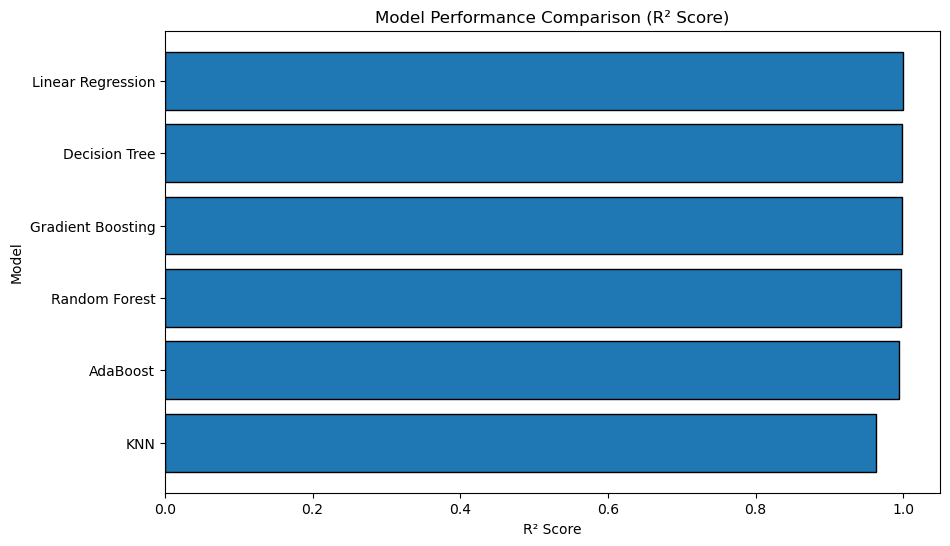

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["R2_Score"], edgecolor="black")
plt.title("Model Performance Comparison (R² Score)")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.show()

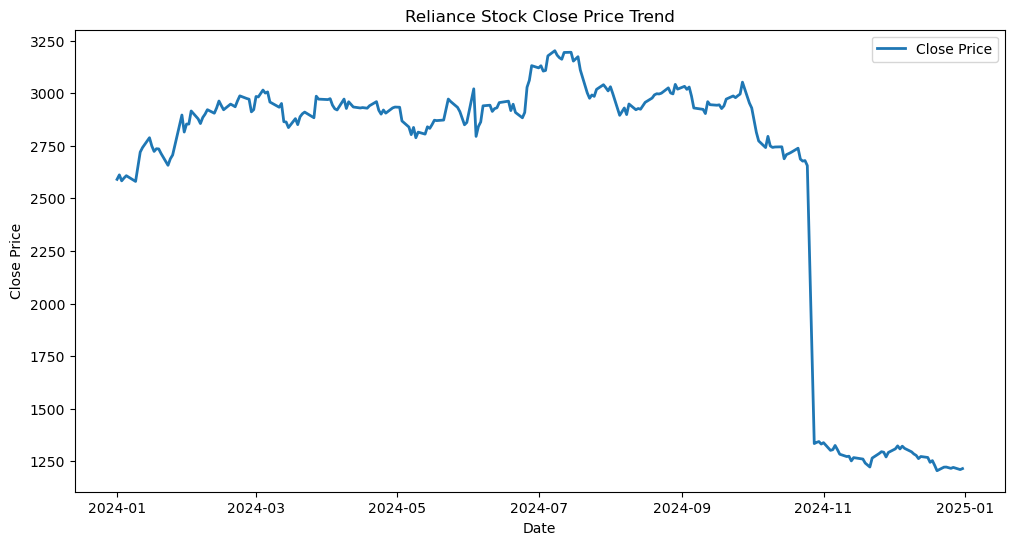

In [23]:
# Plot overall Close price trend
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Close Price", linewidth=2)
plt.title("Reliance Stock Close Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

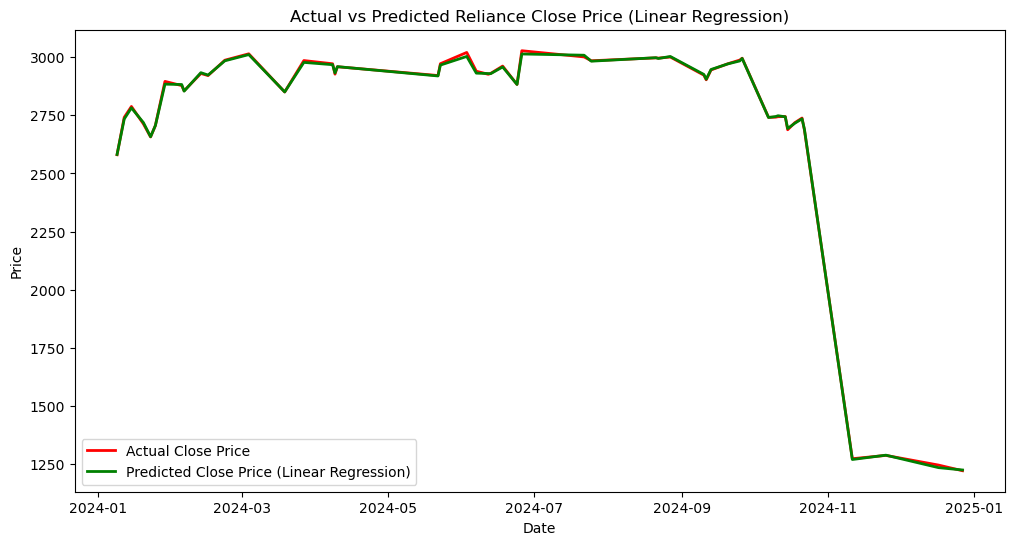

In [24]:
# Actual vs Predicted (Linear Regression) with Date on x-axis
df_test = df.loc[X_test.index].copy()
df_test["Actual_Close"] = y_test
df_test["Predicted_Close_LR"] = pred_lr

df_test = df_test.sort_values("Date")

plt.figure(figsize=(12, 6))
plt.plot(df_test["Date"], df_test["Actual_Close"], label="Actual Close Price", color="red",linewidth=2)
plt.plot(df_test["Date"], df_test["Predicted_Close_LR"], label="Predicted Close Price (Linear Regression)", color="green",linewidth=2)
plt.title("Actual vs Predicted Reliance Close Price (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [25]:
# Future prediction from 2025-01-01 to 2025-12-30 using Linear Regression

future_dates = pd.date_range(start="2025-01-01", end="2025-12-30")
future_df = pd.DataFrame({"Date": future_dates})

# Generate date-based features
future_df["Day"] = future_df["Date"].dt.day
future_df["Month"] = future_df["Date"].dt.month
future_df["Year"] = future_df["Date"].dt.year

# Use last known row for other features (simple assumption)
last_row = df.iloc[-1]

future_df["Open"] = last_row["Open"]
future_df["High"] = last_row["High"]
future_df["Low"] = last_row["Low"]
future_df["Volume"] = last_row["Volume"]
future_df["HL_Perc"] = last_row["HL_Perc"]
future_df["OC_Perc"] = last_row["OC_Perc"]

# Scale future data
future_scaled = scaler.transform(future_df[feature_cols])

# Predict future Close prices using Linear Regression
future_predictions = lr.predict(future_scaled)

future_df["Predicted_Close"] = future_predictions
future_predictions_df = future_df[["Date", "Predicted_Close"]]
future_predictions_df.head()

,Date,Predicted_Close
0,2025-01-01,1223.30452
1,2025-01-02,1223.26573
2,2025-01-03,1223.22694
3,2025-01-04,1223.18815
4,2025-01-05,1223.14936


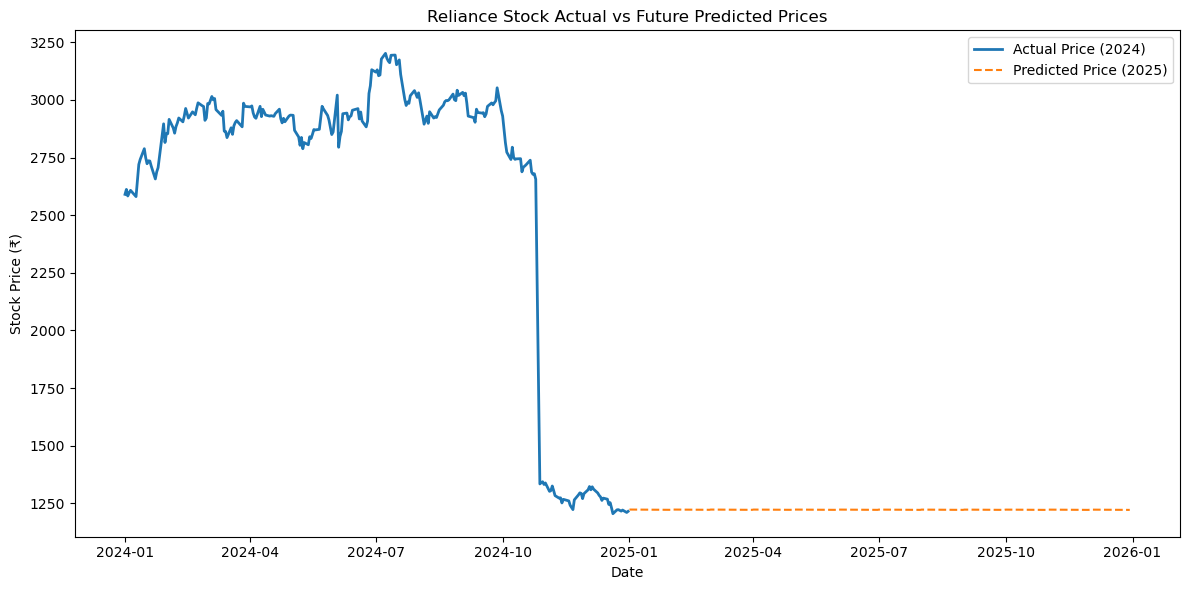

In [26]:
# Plot future predictions
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Close"],label="Actual Price (2024)", linewidth=2)

plt.plot(future_df["Date"], future_df["Predicted_Close"],label="Predicted Price (2025)", linestyle="--")

plt.xlabel("Date")
plt.ylabel("Stock Price (₹)")
plt.title("Reliance Stock Actual vs Future Predicted Prices")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import joblib

# Map model names to actual fitted objects
model_objects = {"Linear Regression": lr,"KNN": knn,"Decision Tree": dt,"Random Forest": rf,"Gradient Boosting": gb,"AdaBoost": ada}

best_model_name = results_df.iloc[0]["Model"]
best_model_obj = model_objects[best_model_name]

print("Saving best model:", best_model_name)

# Save for Streamlit
joblib.dump(best_model_obj, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

Saving best model: Linear Regression


['feature_cols.pkl']